In [5]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from matplotlib import cm, ticker, transforms
import matplotlib.colors as mcolors
from types import DynamicClassAttribute
import math
import time
import matplotlib.patches as patches
#import sympy as sp
from itertools import combinations_with_replacement, product
#from scipy import linalg
from matplotlib import cm
from matplotlib.ticker import LinearLocator
from matplotlib.colors import LogNorm

from functools import reduce
import operator

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

Unknown-model barrier

Symbiotic Interactions (A):
[[0.         0.         0.         0.01512291 0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.01172245 0.        ]
 [0.01151452 0.         0.01097354 0.         0.01394641]
 [0.         0.         0.         0.01374584 0.        ]]
Growth Rates (r):
[0.2211673  0.27012303 0.26486458 0.25535394 0.21807401]
Carrying Capacities (K):
[4.88766028 4.47019419 2.99394925 3.25158737 4.89276203]


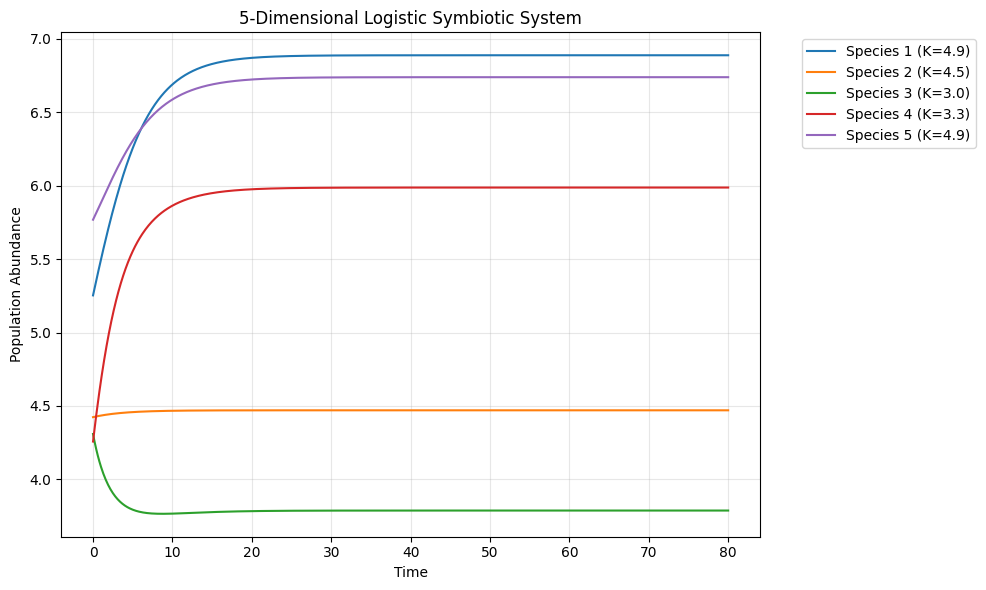

In [6]:
from scipy.integrate import solve_ivp

def create_logistic_lv_derivative(A, r, K):
    """
    Creates the derivative function for a Lotka-Volterra system with Logistic Growth.
    
    Parameters:
    A (np.ndarray): Non-negative symbiotic interaction matrix (n x n).
    r (np.ndarray): Positive intrinsic growth vector (n,).
    K (np.ndarray): Positive carrying capacity vector (n,).
    
    Returns:
    function: The derivative function dxdt(t, x).
    """
    def dxdt(t, x):
        x = np.maximum(x, 0) # Safety check for non-negative populations
        
        # Logistic term: r * (1 - x/K)
        # Note: We divide x by K element-wise
        logistic_growth = r * (1 - (x / K))
        
        # Symbiotic term: A @ x
        symbiotic_boost = A @ x
        
        # Combine: dx/dt = x * (Logistic + Symbiosis)
        return x * (logistic_growth + symbiotic_boost)
    
    return dxdt

def generate_logistic_symbiotic_parameters(n, connection_prob=0.5):
    """
    Generates random parameters including Carrying Capacity (K).
    """
    # 1. Generate Growth Rates (r) and Carrying Capacities (K)
    r = np.random.uniform(0.2, 0.3, size=n)
    K = np.random.uniform(2.0, 5.0, size=n) # Populations naturally cap around 5-10 units
    
    # 2. Generate the Symbiotic Matrix A
    # We keep the interaction coefficients small so they don't 
    # immediately overpower the carrying capacity.
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            if np.random.random() < connection_prob:
                # Symbiosis constraint: Aij > 0 and Aji > 0
                val_ij = np.random.uniform(0.01, 0.02)
                val_ji = np.random.uniform(0.01, 0.02)
                A[i, j] = val_ij
                A[j, i] = val_ji
                
    return A, r, K

# --- Example Usage ---

# 1. Define dimensions
n = 5

# 2. Generate parameters
A_matrix, r_vector, K_vector = generate_logistic_symbiotic_parameters(n)
# A_matrix = np.array([[0.,         0.01731471, 0.01209135],
#             [0.0149744,  0.,         0.        ],
#             [0.01098677, 0.,         0.        ]])
# r_vector = np.array([0.2207373,  0.22070226, 0.27930457])
# K_vector = np.array([4.37816587, 3.05526956, 3.75092502])
print(f"Symbiotic Interactions (A):\n{A_matrix}")
print(f"Growth Rates (r):\n{r_vector}")
print(f"Carrying Capacities (K):\n{K_vector}")

# 3. Create the system
lv_logistic_system = create_logistic_lv_derivative(A_matrix, r_vector, K_vector)

# 4. Simulate
# We can run this for longer (e.g., t=50) because K prevents infinite blow-up
t_span = (0, 80) 
x0 = np.random.uniform(4, 6, size=n) 

solution = solve_ivp(lv_logistic_system, t_span, x0, max_step=0.1)

# 5. Plotting
plt.figure(figsize=(10, 6))
for i in range(n):
    plt.plot(solution.t, solution.y[i], label=f'Species {i+1} (K={K_vector[i]:.1f})')

plt.title(f'{n}-Dimensional Logistic Symbiotic System')
plt.xlabel('Time')
plt.ylabel('Population Abundance')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


# Get the final population values from the previous simulation
final_populations = solution.y[:, -1]


In [7]:
# Dynamical system Lotka-Volterra population dynamics https://ucsb.app.box.com/s/64opq9gh815eqpojnk77vjeo7yekbsm5 Section 4.4
## MUTUALISM: While no single ecosystem holds the absolute largest number of mutualistic species, 
# tropical rainforests and coral reefs are recognized as having the most species overall, 
# with mutualisms (like pollination, seed dispersal, and fungi-plant relationships) being 
# fundamental drivers of this immense diversity, especially in plants, while the sheer 
# volume of insect-plant interactions in rainforests is staggering. 

dim = 5
if dim == 5:
## start:Define functions
    A = np.array([[0.,         0.01609719, 0.,         0.,        0.        ],
                  [0.01398432, 0.,         0.,         0.01986906, 0.0174724 ],
                  [0.,         0.,         0.,         0.01224593, 0.01773106],
                  [0.,         0.01971881, 0.01589185, 0.,         0.        ],
                  [0.,         0.01340343, 0.01094983, 0.,         0.        ]])
    r = np.array([0.21960468, 0.2857656, 0.26390616, 0.25237908, 0.22529947])
    K = np.array([3.8051919, 2.47339365, 4.23266727, 2.93494904, 4.89366099])
elif dim == 2:
    A = np.array([[0.,         0.01348858],
                 [0.01903571,  0.        ]])
    r = np.array([0.22109991, 0.25607854])
    K = np.array([2.91915254, 4.79586622])
else: 
    A = np.array([[0.,         0.01731471, 0.01209135],
                [0.0149744,  0.,         0.        ],
                [0.01098677, 0.,         0.        ]])
    r = np.array([0.2207373,  0.22070226, 0.27930457])
    K = np.array([4.37816587, 3.05526956, 3.75092502])

def find_tau_for_negative_diagonals(x, A, r, K):
    """
    Finds the minimum tau required to make the DIAGONAL elements of J_f non-positive.
    Returns None if impossible (e.g., if the system is locally unstable/growing).
    """
    n = len(x)
    
    # 1. Calculate the diagonal elements of the Continuous Jacobian (J_ODE)
    # J_ii = r_i*(1 - x_i/K_i) + (A@x)_i - x_i*(r_i/K_i) + x_i*A_ii
    # Simplifies to: r_i - 2*r_i*x_i/K_i + (A@x)_i + x_i*A_ii
    
    symbiosis_boost = A @ x
    # Note: A has 0 on diagonal usually, but we include it for generality
    J_ode_diag = r * (1 - 2*x/K) + symbiosis_boost + np.diag(A)*x
    
    print(f"Continuous Jacobian Diagonals (J_ODE_ii):\n{J_ode_diag}")
    
    # 2. Check Feasibility
    # We need 1 + tau * J_ii <= 0  =>  tau * J_ii <= -1
    # If J_ii is positive (growth phase), we can never make it <= -1 with positive tau.
    
    if np.any(J_ode_diag >= 0):
        print("\nImpossible: At least one species is in a growth phase (J_ii >= 0).")
        print("Increasing tau will only make the diagonal larger (1 + positive).")
        return None
        
    # 3. Solve for Tau
    # tau >= -1 / J_ii
    # Since J_ii is negative, -1/J_ii is positive.
    # We need this to hold for ALL i, so we take the maximum of the required taus.
    
    required_taus = -1.0 / J_ode_diag
    min_tau = np.max(required_taus)
    
    return min_tau

# --- Test with your parameters ---

# Case: High population (Overshoot) -> Possible
x_high = np.array([10]*dim)
print("\n--- Case 2: High Population (x = Xub) ---")
tau_high = find_tau_for_negative_diagonals(x_high, A, r, K)
x_low = np.array([0.1]*dim)
print("\n--- Case 1: Low Population (x = Xlb) ---")
tau_low = find_tau_for_negative_diagonals(x_low, A, r, K)
if tau_high:
    print(f"\nResult: Tau must be >= {tau_high:.4f} to make diagonals non-positive.")
if tau_low:
    print(f"\nResult: Tau must be >= {tau_low:.4f} to make diagonals non-positive.")
    
tau = 0.2
def compute_jacobian(x, A, r, K, tau):
    """
    Computes the Jacobian for the vector field:
    x_next = x + tau * diag(x) * [Ax + r - diag(r/K)x]
    """
    n = len(x)
    # Term inside the brackets: b = Ax + r - (r/K)*x
    bracket_term = A @ x + r - (r / K) * x
    
    # Off-diagonal part: tau * x_i * A_ij
    # np.outer(x, np.ones(n)) * A creates a matrix where row i is multiplied by x_i
    J = tau * (x[:, np.newaxis] * A)
    
    # Diagonal part: 1 + tau * [bracket_term_i + x_i * (A_ii - r_i/K_i)]
    diag_indices = np.diag_indices(n)
    diag_values = 1 + tau * (bracket_term + x * (np.diag(A) - r / K))
    
    J[diag_indices] = diag_values
    
    return J
jac_high = compute_jacobian(x_high, A, r, K, tau)
#print("Jacobian Matrix:\n", jac)
inf_norm_high = np.linalg.norm(jac_high, np.inf)
print(f"Induced Infinity Norm (High): {inf_norm_high}")
jac_low = compute_jacobian(x_low, A, r, K, tau)
#print("Jacobian Matrix:\n", jac)
inf_norm_low = np.linalg.norm(jac_low, np.inf)
print(f"Induced Infinity Norm (Low): {inf_norm_low}")
def fdt(x,u=0):
    x = np.array(x)
    u = np.array(u)
    x = x + tau * (x * (r * (1 - (x / K)) + A @ x))
    return x

def dynsys(x0,U,T=1,rounding=64):
    x0 = np.array(x0)
    U = np.array(U)
    x = []
    for j in range(T):
      x.append(x0)
      x0 = x[-1]
      x0 = fdt(x0,U[j])
    return np.round(x,rounding)
## end:Define functions



--- Case 2: High Population (x = Xub) ---
Continuous Jacobian Diagonals (J_ODE_ii):
[-0.7736605  -1.51169329 -0.6833209  -1.11133348 -0.4519488 ]

--- Case 1: Low Population (x = Xlb) ---
Continuous Jacobian Diagonals (J_ODE_ii):
[0.20967203 0.26779101 0.25443389 0.23874195 0.21852699]

Impossible: At least one species is in a growth phase (J_ii >= 0).
Increasing tau will only make the diagonal larger (1 + positive).

Result: Tau must be >= 2.2126 to make diagonals non-positive.
Induced Infinity Norm (High): 0.958316760975027
Induced Infinity Norm (Low): 1.0545847178102927


In [8]:
# from scipy.optimize import linprog

# class MonotonicityDomainAnalyzer:
#     def __init__(self, A):
#         """
#         Initialize with the Metzler matrix A.
#         """
#         self.A = np.array(A)
#         self.n = self.A.shape[0]
        
#         # Construct A_mod
#         # A_mod is the same as A, but with diagonal elements doubled.
#         # This comes from the condition: 2*A_ii*x_i + sum(A_ij*x_j) >= 0
#         self.A_mod = np.copy(self.A)
#         np.fill_diagonal(self.A_mod, 2 * np.diag(self.A))

#     def get_constraint_matrix(self):
#         """Returns the matrix A_mod defining the domain inequalities A_mod * x >= 0"""
#         return self.A_mod

#     def is_in_domain(self, x):
#         """Checks if a specific vector x is in the monotonicity domain."""
#         x = np.array(x)
#         if np.any(x < 0): return False # x must be non-negative
        
#         # Check inequality: A_mod @ x >= 0
#         condition = self.A_mod @ x
#         return np.all(condition >= -1e-9) # Tolerance for float errors

#     def find_interior_point(self):
#         """
#         Uses Linear Programming to find a vector 'x' deep inside the cone.
#         Maximizes the minimum margin slack.
#         """
#         # We want to find x such that A_mod @ x >= s (where s is slack)
#         # and maximize s.
#         # Constraints:
#         # 1. A_mod @ x - s >= 0
#         # 2. sum(x) = 1 (normalization to prevent infinite solution)
#         # 3. x >= 0, s >= 0
        
#         c = [-1] + [0]*self.n  # Minimize -s (Maximize s)
        
#         # Inequality matrix for scipy.linprog (upper bound form: A_ub * x <= b_ub)
#         # We rewrite A_mod @ x - s >= 0  as  -A_mod @ x + s <= 0
        
#         # Construct the matrix combining s and x
#         # Column 0 is s, Columns 1..n are x
#         A_ub = np.hstack([np.ones((self.n, 1)), -self.A_mod])
#         b_ub = np.zeros(self.n)
        
#         # Equality constraint: sum(x) = 1
#         A_eq = np.array([[0] + [1]*self.n])
#         b_eq = np.array([1])
        
#         # Bounds: s in [0, inf), x_i in [0, inf)
#         bounds = [(0, None)] + [(0, None)]*self.n
        
#         res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
        
#         if res.success and res.x[0] > 1e-5:
#             return res.x[1:] # Return the x vector
#         else:
#             return None # Domain is likely trivial (only x=0)

#     def plot_2d_domain(self):
#         """Visualizes the cone for 2D matrices."""
#         if self.n != 2:
#             print("Plotting is only supported for 2D matrices.")
#             return
            
#         x = np.linspace(0, 10, 100)
        
#         # Define the lines from inequalities
#         # Line 1: A_mod[0,0]x1 + A_mod[0,1]x2 >= 0  ->  x2 >= -(A_mod[0,0]/A_mod[0,1])x1
#         # Line 2: A_mod[1,0]x1 + A_mod[1,1]x2 >= 0  ->  x2 >= -(A_mod[1,0]/A_mod[1,1])x1
        
#         # Safe division helper
#         def get_slope(row_idx):
#             a1, a2 = self.A_mod[row_idx]
#             if a2 == 0: return float('inf')
#             return -a1 / a2

#         slope1 = get_slope(0)
#         slope2 = get_slope(1)
        
#         plt.figure(figsize=(8, 8))
        
#         # Generate lines
#         y1 = slope1 * x
#         y2 = slope2 * x
        
#         # Plot lines
#         plt.plot(x, y1, '--', label='Constraint 1 (Species 1 ok)', color='blue')
#         plt.plot(x, y2, '--', label='Constraint 2 (Species 2 ok)', color='green')
        
#         # Fill the valid region (Monotonicity Domain)
#         # The logic for filling depends on the slopes, but generally it's "between" the lines
#         # if a valid cone exists in the first quadrant.
        
#         # We sample points to visualize the region clearly
#         grid_x, grid_y = np.meshgrid(np.linspace(0, 10, 200), np.linspace(0, 10, 200))
        
#         # Evaluate A_mod @ x for every point in grid
#         val1 = self.A_mod[0,0]*grid_x + self.A_mod[0,1]*grid_y
#         val2 = self.A_mod[1,0]*grid_x + self.A_mod[1,1]*grid_y
        
#         mask = (val1 >= 0) & (val2 >= 0)
        
#         plt.imshow(mask, extent=(0,10,0,10), origin='lower', cmap='Greys', alpha=0.3)
#         plt.plot([],[], color='gray', alpha=0.3, label='Valid Domain') # Dummy for legend

#         plt.xlim(0, 10)
#         plt.ylim(0, 10)
#         plt.title('Domain of Monotonicity (2D)')
#         plt.xlabel('x1 (Species 1)')
#         plt.ylabel('x2 (Species 2)')
#         plt.legend()
#         plt.grid(True, alpha=0.3)
#         plt.show()

# # --- Example Usage ---

# # Case: Strong Symbiosis (Valid Domain exists)
# # Diagonals are -1 (limiting), Off-diagonals are 0.8 (strong cooperation)
# A_strong = [
#     [-1.0, 0.8], 
#     [0.8, -1.0]
# ]

# analyzer = MonotonicityDomainAnalyzer(A_strong)

# # 1. Get the defining matrix
# print("Constraint Matrix A_mod:\n", analyzer.get_constraint_matrix())

# # 2. Find a feasible vector
# feasible_x = analyzer.find_interior_point()
# print("\nFeasible Vector in Domain:", feasible_x)

# # 3. Check a random point
# test_x = [5, 5]
# print(f"Is {test_x} in domain?", analyzer.is_in_domain(test_x))

# # 4. Plot
# analyzer.plot_2d_domain()

Initial conditions for trajectories: 
 [[1.46335893 0.83737139 0.67492067 1.59297645 0.78170266]
 [8.65318721 9.74127851 8.83348359 9.17014017 9.6081883 ]]
(400, 5)
t= 0 x(t)= [1.463359 0.837371 0.674921 1.592976 0.781703]
t= 40 x(t)= [3.511888 3.282358 3.580055 3.563623 3.423358]
t= 80 x(t)= [4.832632 4.801717 6.732524 5.028701 7.066544]
t= 120 x(t)= [5.204403 5.238961 7.542454 5.485426 8.10084 ]
t= 160 x(t)= [5.276367 5.311278 7.661274 5.562454 8.24765 ]
t= 200 x(t)= [5.287919 5.321428 7.676979 5.573143 8.266882]
t= 240 x(t)= [5.289628 5.322813 7.679048 5.574576 8.269419]
t= 280 x(t)= [5.289871 5.323001 7.679322 5.574768 8.269756]
t= 320 x(t)= [5.289905 5.323027 7.679359 5.574794 8.269802]
t= 360 x(t)= [5.289909 5.32303  7.679364 5.574797 8.269808]
t= 399 x(t)= [5.28991  5.323031 7.679365 5.574798 8.269808]


/tmp/ipykernel_22214/1997088444.py:74: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figT.show()


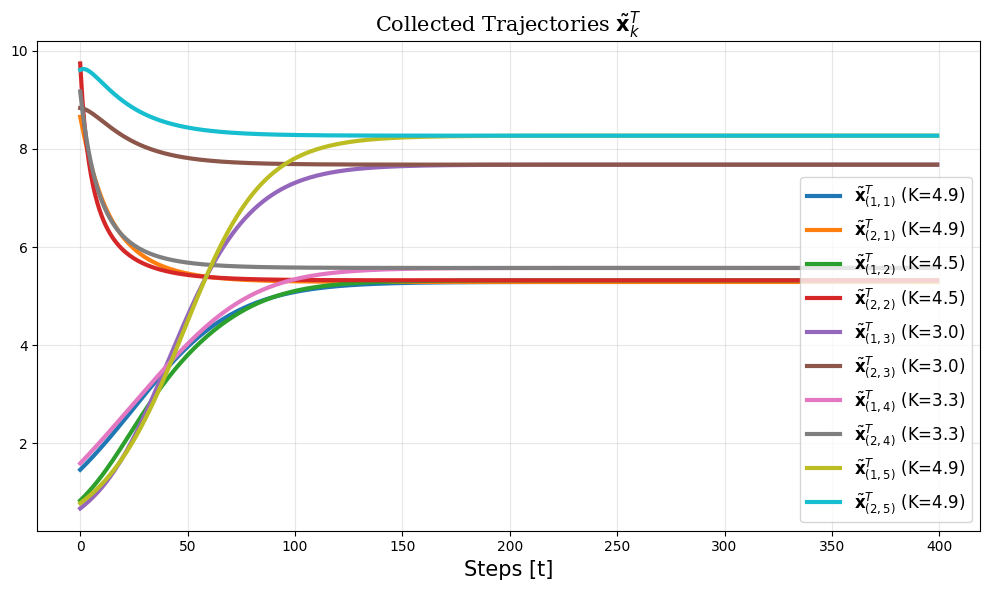

In [9]:
## Test trajectories
dim_input = 3 # Dimension of the input space
# Parameters
rounding = 6
gain = 1
granularity = 0.5
bounds = [(0, 10)]*dim
U = np.array([-2.0,-1.0,0.0,0.5,1.0,1.5,2.0])  # Control inputs

## Safety problem: State Set, Initial Set, Unsafe Set, 
#Initial Set
x0lb = np.array([4]*dim)
x0ub = np.array([6]*dim)

#Unsafe Set 1
xUlb = np.array([0]*dim)
xUub = np.array([2]*dim) 
#Unsafe Set 2
xUlb2 = np.array([8]*dim)
xUub2 = np.array([10]*dim)

NSol = 2
T = int(80/tau)
n_split = int(np.floor(NSol / 2))
n_remainder = NSol - n_split

# 2. Extract environment limits from the 'bounds' list
# bounds is usually a list of tuples like [(-5, 5), (-5, 5)]
# We convert them to arrays to allow vectorized uniform generation
env_mins = np.array([b[0] for b in bounds]) # e.g. [-5, -5]
env_maxs = np.array([b[1] for b in bounds]) # e.g. [ 5,  5]

# 3. Generate the two parts
# Part 1: Range [Environment Min, x0lb]
#x0_part1 = np.random.uniform(low=env_mins, high=x0lb-2, size=(n_split, dim))

# Part 2: Range [x0ub, Environment Max]
#x0_part2 = np.random.uniform(low=x0ub+2, high=env_maxs, size=(n_remainder, dim))

x0_part1 = np.array([[1.46335893, 0.83737139, 0.67492067, 1.59297645, 0.78170266]])
x0_part2 = np.array([[8.65318721, 9.74127851, 8.83348359, 9.17014017, 9.6081883 ]])
# 4. Concatenate to form the final array
x0 = np.concatenate([x0_part1, x0_part2], axis=0)

print("Initial conditions for trajectories: \n",x0)

input_u1 = 0*np.ones((T,dim_input))  # Control input for first half of the trajectory

input_u = np.tile(input_u1[np.newaxis, :, :], (NSol, 1, 1))
trajectory = np.array([dynsys(x0[i], input_u[i], T, rounding) for i in range(NSol)])

solution = trajectory[0,:,:]
print(solution.shape)
arr = np.arange(0, T+1, int(T/10))
for i in arr:
    if i == T:
        print("t=",i-1,"x(t)=",solution[i-1,:])
    else:
        print("t=",i,"x(t)=",solution[i,:])
# 5. Plotting

figT,axT = plt.subplots(figsize = (10,6))
for i in range(dim):
    axT.plot(trajectory[0,:, i],linewidth=3, label=f'$\\tilde{{\\mathbf{{x}}}}^T_{{{1,i+1}}}$ (K={K_vector[i]:.1f})')
    axT.plot(trajectory[1,:, i], linewidth=3, label=f'$\\tilde{{\\mathbf{{x}}}}^T_{{{2,i+1}}}$ (K={K_vector[i]:.1f})')


axT.set_title('Collected Trajectories $\\tilde{\\mathbf{x}}^T_k$', fontfamily='serif', fontsize=15)
axT.set_xlabel('Steps [t]', fontsize=15)
axT.set_ylabel('', fontsize=15)
axT.legend(loc='lower right', fontsize=12)#bbox_to_anchor=(1.05, 1), loc='upper left')
figT.tight_layout()
axT.grid(True, alpha=0.3)
figT.show()
figT.savefig('ex_nonlinear_barrier.pdf', format='pdf')

In [10]:
## Create grid and compute PP and QQ
axes = [np.arange(b[0], b[1] + granularity, granularity) for b in bounds]
grids = np.meshgrid(*axes)
X = np.stack(grids, axis=-1)
grid_shape = X.shape[:-1]

# Initialize fP with 1.1
fP = np.full((NSol, *grid_shape), gain*1.1, dtype=float)
fPP = np.empty((NSol,*grid_shape, 1+dim_input), dtype=float)
fPP[..., 0] = gain * 1.1
fPP[..., 1:] = np.min(U)#U[np.argmin(np.sum(U, axis=1))]

# Vectorized time iteration
for t in range(T):
    # Dynamically expand trajectory for broadcasting to match grid dimensions
    traj_expanded = trajectory[:, t][(slice(None),) + (np.newaxis,) * len(grid_shape) + (slice(None),)]
    mask = np.all(X[None, ...] <= traj_expanded, axis=-1)  # shape (NSol, *grid_shape)
    update_vals = np.round(gain*1.0 / (1 + t), rounding)   
    fP = np.where(mask & (update_vals < fP), update_vals, fP)
    # Update fPP[..., 0] as in fP
    fPP[:, ..., 0] = np.where(mask & (update_vals < fPP[:, ..., 0]), update_vals, fPP[:, ..., 0])
    # Update fPP[..., 1:] with input_u for each NSol, vectorized
    # Create proper shape for input_u broadcasting: (NSol, dim_input) -> (NSol, 1, 1, ..., 1, dim_input)
    input_u_expanded = input_u[:, t][(slice(None),) + (np.newaxis,) * len(grid_shape) + (slice(None),)]
    fPP[:, ..., 1:] = np.where(mask[..., None], input_u_expanded, fPP[:, ..., 1:])

# Initialize fP with 1.1
fQ = np.full((NSol, *grid_shape), gain*1.1, dtype=float)
fQQ = np.empty((NSol, *grid_shape, 1+dim_input), dtype=float)
fQQ[..., 0] = gain * 1.1
fQQ[..., 1:] = np.max(U)  # U[np.argmin(np.sum(U, axis=1))]

# Vectorized time iteration
for t in range(T):
    # Dynamically expand trajectory for broadcasting to match grid dimensions
    traj_expanded = trajectory[:, t][(slice(None),) + (np.newaxis,) * len(grid_shape) + (slice(None),)]
    mask = np.all(X[None, ...] >= traj_expanded, axis=-1)  # shape (NSol, *grid_shape)
    update_vals = np.round(gain*1.0 / (1 + t), rounding)
    fQ = np.where(mask & (update_vals < fQ), update_vals, fQ)
    # Update fQQ[..., 0] as in fQ
    fQQ[:, ..., 0] = np.where(mask & (update_vals < fQQ[:, ..., 0]), update_vals, fQQ[:, ..., 0])
    # Update fQQ[..., 1:] with input_u for each NSol, vectorized
    # Create proper shape for input_u broadcasting: (NSol, dim_input) -> (NSol, 1, 1, ..., 1, dim_input)
    input_u_expanded = input_u[:, t][(slice(None),) + (np.newaxis,) * len(grid_shape) + (slice(None),)]
    fQQ[:, ..., 1:] = np.where(mask[..., None], input_u_expanded, fQQ[:, ..., 1:])


fT = np.concatenate([fP, fQ], axis=0)
fTT = np.concatenate([fPP, fQQ], axis=0)
print("Granularity of Barrier grid: ",granularity)
print("Check final value of trajectories:\n",np.array([trajectory[k][-1] for k in range(NSol)]))
print("X dimension",X.shape,"fTT dimension", fTT.shape,"trajectory dimension",trajectory.shape,"input_u dimension",input_u.shape)



Granularity of Barrier grid:  0.5
Check final value of trajectories:
 [[5.28991  5.323031 7.679365 5.574798 8.269808]
 [5.28991  5.323031 7.679365 5.574798 8.269809]]
X dimension (21, 21, 21, 21, 21, 5) fTT dimension (4, 21, 21, 21, 21, 21, 4) trajectory dimension (2, 400, 5) input_u dimension (2, 400, 3)


Basis function:  fQ . Trajectory:  1


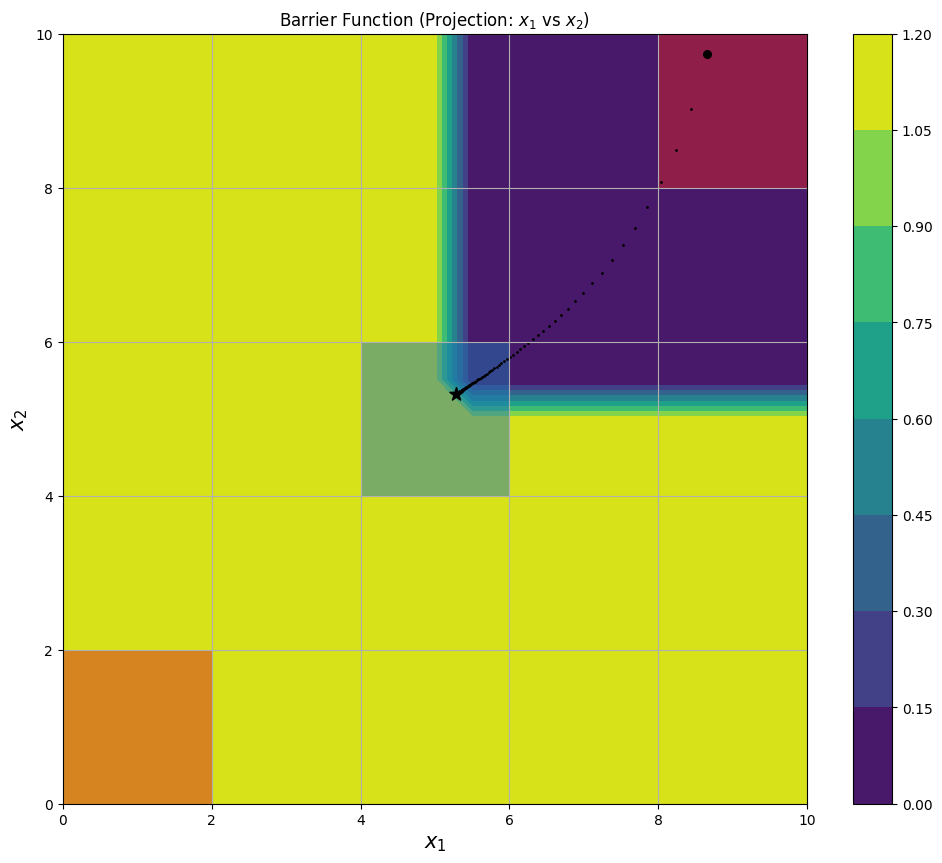

In [11]:
# PLOT2: Dynamical system - generalized for arbitrary dimensions
fig2, ax2 = plt.subplots(figsize=(12, 10))

idx = np.random.randint(0, 2*NSol)
if idx >= NSol:
    basisfcn = 'fQ'
else:
    basisfcn = 'fP'
print('Basis function: ', basisfcn, '. Trajectory: ', idx%NSol)

# ======= CUSTOMIZE HERE: Select dimensions to project =======
dim_x = 0  # dimension for x-axis (change to 0, 1, 2, ... for different dimensions)
dim_y = 1  # dimension for y-axis (change to 0, 1, 2, ... for different dimensions)
# ============================================================

data_slice = fTT[idx]

if dim == 2:
    # Full 2D slice
    X1 = X[..., 0]
    X2 = X[..., 1]
    Z  = data_slice[..., 0] # The value channel
        
    slice_label = "Full 2D Domain"
        
else:
    # Higher dimension: Slice at fixed indices as requested
    # You requested: fTT[idx, :, :, -1, ..., -1, 0]
    # We slice the spatial dimensions. 
    # For a 3D grid (n1, n2, n3), we take (:, :, -1).
        
    # Slicing logic:
    # We take all elements of the first two dimensions, and the LAST element of the remaining spatial dims
    slicer = tuple([slice(None)] * 2 + [ -1 ] * (dim - 2))
        
    X1 = X[slicer][..., 0] # Sliced X coords
    X2 = X[slicer][..., 1] # Sliced Y coords
    Z  = data_slice[slicer][..., 0] # Sliced Values
        
    slice_label = f"Sliced at last indices of dims > 2"


cs = ax2.contourf(X1,X2,Z)
# Create Rectangle patches for unsafe and initial regions
XUpp = patches.Rectangle((xUlb[dim_x], xUlb[dim_y]), 
                          xUub[dim_x] - xUlb[dim_x], xUub[dim_y] - xUlb[dim_y], 
                          linewidth=2, edgecolor='None', facecolor='tab:red', alpha=0.5)
XU2pp = patches.Rectangle((xUlb2[dim_x], xUlb2[dim_y]), 
                           xUub2[dim_x] - xUlb2[dim_x], xUub2[dim_y] - xUlb2[dim_y], 
                           linewidth=2, edgecolor='None', facecolor='tab:red', alpha=0.5)
X0pp = patches.Rectangle((x0lb[dim_x], x0lb[dim_y]), 
                          x0ub[dim_x] - x0lb[dim_x], x0ub[dim_y] - x0lb[dim_y], 
                          linewidth=2, edgecolor='None', facecolor='tab:blue', alpha=0.5)
ax2.add_patch(XUpp)
ax2.add_patch(XU2pp)
ax2.add_patch(X0pp)

# Plot trajectory projection
ax2.scatter(trajectory[idx%NSol, :, dim_x], trajectory[idx%NSol, :, dim_y], 
            s=1, c='black', marker='o', label='Trajectory')
ax2.scatter(trajectory[idx%NSol, 0, dim_x], trajectory[idx%NSol, 0, dim_y], 
            s=30, c='black', marker='o', label='Start', zorder=5)
ax2.scatter(trajectory[idx%NSol, -1, dim_x], trajectory[idx%NSol, -1, dim_y], 
            s=100, c='black', marker='*', label='End', zorder=5)
fig2.colorbar(cs)

# Add labels, title, and legend
plt.xlabel(f'$x_{dim_x+1}$', fontsize=15)
plt.ylabel(f'$x_{dim_y+1}$', fontsize=15)
plt.title(f'Barrier Function (Projection: $x_{dim_x+1}$ vs $x_{dim_y+1}$)')
plt.axis([bounds[dim_x][0], bounds[dim_x][1], bounds[dim_y][0], bounds[dim_y][1]])
plt.grid(True)

In [12]:
def AffCom(vec, max_degree=1):
    vec = np.array(vec)  # Ensure input is a NumPy array
    n = len(vec)  # Number of variables
    
    # For max_degree=1, return [1, x1, x2, ...]
    # Only valid for an affine combination, namely, a polynomial of degree 1
    if max_degree == 1:
        polyvec = np.concatenate([np.array([1.0]), vec], axis=0)
        polydvec = np.zeros((n, len(polyvec)))
        for i in range(n):
            polydvec[i, i+1] = 1.0  # derivative of x_i w.r.t x_i is 1
        return polyvec, polydvec

def PolY(vec, max_degree=1):
    vec = np.array(vec)  # Ensure input is a NumPy array
    n = len(vec)  # Number of variables
    
    # For max_degree=1, return [1, x1, x2, ...]
    if max_degree == 1:
        polyvec = np.concatenate([np.array([1.0]), vec], axis=0)
        polydvec = np.zeros((n, len(polyvec)))
        for i in range(n):
            polydvec[i, i+1] = 1.0  # derivative of x_i w.r.t x_i is 1
        return polyvec, polydvec
    
    # Generate all monomials up to max_degree, including the constant 1
    monomials = [1.0]  # Include the constant term
    for degree in range(1, max_degree + 1):
        for exponents in product(range(degree + 1), repeat=n):
            if sum(exponents) == degree:
                monomial = np.prod([vec[i]**exp for i, exp in enumerate(exponents)])
                monomials.append(monomial)
    
    # Convert monomials to polynomial vector
    polyvec = np.array(monomials, dtype=float)
    
    # Compute derivatives
    polydvec = np.zeros((n, len(monomials)))
    for i in range(n):
        for j, monomial in enumerate(monomials):
            derivative = 0.0
            for degree in range(1, max_degree + 1):
                for exponents in product(range(degree + 1), repeat=n):
                    if sum(exponents) == degree:
                        if exponents[i] > 0:
                            reduced_exponents = list(exponents)
                            reduced_exponents[i] -= 1
                            term = exponents[i] * np.prod([vec[k]**exp for k, exp in enumerate(reduced_exponents)])
                            if np.prod([vec[k]**exp for k, exp in enumerate(exponents)]) == monomial:
                                derivative += term
            polydvec[i, j] = derivative
    
    return polyvec, np.array(polydvec)

In [13]:
def BarT(t,c):
    return t@c

def dBarT(t,dt,ll):
    cc, tt = np.shape(dt)
    #ll = np.ones(tt)
    dd = []
    #print([i for i in range(tt)])
    for ii in range(cc):
        dd.append(ll[ii]*t + dt[ii,:])
    return np.array(dd)   

def dBarT2(dt,c):
    cc, tt = np.shape(dt)
    #ll = np.ones(tt)
    dd = []
    #print([i for i in range(tt)])
    for ii in range(tt):
        dd.append(dt[ii,:]@c)
    return dd  

In [14]:
# Find XU
# 2. Find indices inside the overapproximated unsafe region
mask_list = []
for d in range(dim):
    axis_d = axes[d]
    lb = xUlb[d]
    ub = xUub[d]
    mask_d = (X[..., d] >= max(axis_d[axis_d <= lb])) & \
             (X[..., d] <= min(axis_d[axis_d >= ub]))
    mask_list.append(mask_d)
maskU1 = reduce(operator.and_, mask_list)

mask_list = []
for d in range(dim): 
    axis_d = axes[d]
    lb = xUlb2[d]
    ub = xUub2[d]
    mask_d = (X[..., d] >= max(axis_d[axis_d <= lb])) & \
             (X[..., d] <= min(axis_d[axis_d >= ub]))
    mask_list.append(mask_d)
maskU2 = reduce(operator.and_, mask_list)


maskU = maskU1 | maskU2
indU1 = np.argwhere(maskU1)
indU2 = np.argwhere(maskU2)
indU = np.concatenate((indU1, indU2), axis=0)
# 3. Extract values in the intersection arrays
XU1 = X[maskU1]
XU2 = X[maskU2]
XU = np.concatenate((XU1, XU2), axis=0)
# 4. Find indices of the lowest and largest elements in each dimension
min_indU = np.min(indU, axis=0)
#max_indU = np.max(indU, axis=0)

# 5. Find the lowest and largest values in the intersection
min_XU = np.min(XU, axis=0)
#max_XU = np.max(XU, axis=0)

# Find X0
# 2. Find indices inside the overapproximated initial region
mask_list = []
for d in range(dim):
    axis_d = axes[d]
    lb = x0lb[d]
    ub = x0ub[d]
    mask_d = (X[..., d] >= max(axis_d[axis_d <= lb])) & \
             (X[..., d] <= min(axis_d[axis_d >= ub]))
    mask_list.append(mask_d)
mask0 = reduce(operator.and_, mask_list)
ind0 = np.argwhere(mask0)


# 3. Extract values in the intersection arrays
X0 = X[mask0]

# 4. Find indices of the lowest and largest elements in each dimension
#min_ind0 = np.min(ind0, axis=0)
#max_ind0 = np.max(ind0, axis=0)

# 5. Find the lowest and largest values in the intersection
#min_X0 = np.min(X0, axis=0)
#max_X0 = np.max(X0, axis=0)


# 3. Extract values in the complement arrays
X_comp = X[~maskU]
ind_X_comp = np.argwhere(~maskU)

# Display results
#print("Lowest indices in XU:", min_indU,", Lowest values in XU:", min_XU)
#print("Largest indices in X0:", max_ind0,", Largest values in X0:", max_X0)


print("Total elements in the grid ", X.shape[0]*X.shape[1])
print("Elements of Initial Set ", ind0.shape)
print("Elements of Unsafe Set ",indU.shape)
print("Elements of X\XU ",ind_X_comp.shape)


Total elements in the grid  441
Elements of Initial Set  (3125, 5)
Elements of Unsafe Set  (6250, 5)
Elements of X\XU  (4077851, 5)


In [15]:
consT = []
epsT = 0.001
maxdeg = 1
# Recall fT(x) = [fP(x),fQ(x)] fP is monotone and fQ is anti-monotone
vec,_ = AffCom(fTT[:,*[0]*dim,0],maxdeg)
lenPoly = len(vec)
ll = 0.0*np.ones(lenPoly)
cTm = cp.Variable(lenPoly,nonneg=True,value = [1]*(lenPoly))
cTM = cp.Variable(lenPoly,nonneg=True,value = [1]*(lenPoly))
cT = cp.Variable(lenPoly,value = [0]*(lenPoly))

# --- 
lb = 1e-4
ub = 1e4
BoolcT = cp.Variable(2*NSol, boolean=True)

# Create cells based on sampled points (X,X0,XU,X_comp). If xm <= x <= xM then [fP(xm), fQ(xM)] <= fT(x) <= [fP(xM), fQ(xm)]
# Initial conditions
for ind in range(ind0.shape[0]):
    indd = ind0[ind,:]+1
    indM = np.flatnonzero((indd==ind0).all(1))
    if indM.size != 0:
        indM = indM[0]
        vecP = fPP[:, *ind0[indM,:],0]
        vecQ = fQQ[:, *ind0[ind,:],0]
        vecT, _ = AffCom(np.concatenate([vecP, vecQ], axis=0), maxdeg)
        consT.append(BarT(vecT,cT)<=-epsT)

# Unsafe conditions
for ind in range(indU.shape[0]):
    indd = indU[ind,:]+1
    indM = np.flatnonzero((indd==indU).all(1))
    if indM.size != 0:
        indM = indM[0]
        vecP = fPP[:, *indU[ind,:],0]
        vecQ = fQQ[:, *indU[indM,:],0]
        vecT, _ = AffCom(np.concatenate([vecP, vecQ], axis=0), maxdeg)
        consT.append(BarT(vecT,cT)>=100*epsT)


# Constraints for Monotonicity of barrier (except the first element)
    for i in range(1, lenPoly):
        consT.append(cT[i] >= 0)



In [27]:
timestart = time.time()
obj = cp.Minimize(0)
prob = cp.Problem(obj,consT)
# The optimal objective value is returned by `prob.solve()`.
result = prob.solve(solver=cp.GUROBI)#solver=cp.GUROBI
# The optimal value for c is stored in `c.value`.
if prob.status not in ["optimal", "optimal_inaccurate"]:
    print(f"Warning: Problem status is '{prob.status}'. No optimal solution found.")
else: print("Optimal:", result, "coefficients:", cT.value)
timeend = time.time()
print('Time taken for optimization: {:.4f} seconds'.format(timeend - timestart))

# If AffCom degree = 1, then cT multiplies (1, P1, P2,...PNSol, Q1, Q2,...QNSol)

Optimal: 0.0 coefficients: [-0.06942903  0.          0.66261659  1.50995393  0.        ]
Time taken for optimization: 7.2865 seconds


In [17]:
# Barrier

# Get the shape of the grid (excluding NSol)
grid_shape = fTT.shape[1:1+dim]  # e.g., (len(x), len(y), ...) for N dims

# Prepare an empty array for BXT
BXT = np.empty(grid_shape)

# Iterate over all grid points using product
for idx in product(*[range(s) for s in grid_shape]):
    # idx is a tuple of indices for each dimension, e.g., (i, j, k, ...)
    BXT[idx] = BarT(AffCom(fTT[(slice(None),) + idx + (0,)], maxdeg)[0], cT.value)

BXT = np.array(BXT)

In [18]:
if dim == 2:
    fig, (ax2) = plt.subplots(figsize = (9,8) )

    ax2.set_axisbelow(True)
    ax2.yaxis.grid(color='gray', linestyle='dashed')  
    ax2.grid(True)

    cs = ax2.contourf(X1,X2,BXT,levels=np.array([np.min(BXT),0.00, np.max(BXT)]),alpha=0.6)

    # Create a Rectangle patch
    XU = patches.Rectangle((xUlb[0], xUlb[1]), xUub[0]-xUlb[0], xUub[1]-xUlb[1], linewidth=2, edgecolor='None', facecolor='tab:red', alpha = 0.8)
    XU2 = patches.Rectangle((xUlb2[0], xUlb2[1]), xUub2[0]-xUlb2[0], xUub2[1]-xUlb2[1], linewidth=2, edgecolor='None', facecolor='tab:red', alpha = 0.8)
    X0 = patches.Rectangle((x0lb[0], x0lb[1]), x0ub[0]-x0lb[0], x0ub[1]-x0lb[1], linewidth=2, edgecolor='None', facecolor='tab:blue', alpha = 0.8)

    ax2.annotate('$\\mathcal{X}_0$',fontsize = 25, color = 'k',xy = ((x0ub[0]+x0lb[0])/2-0.3, (x0ub[1]+x0lb[1])/2-0.2))#math.degrees(math.atan(x0[0]/x0[1])))
    ax2.annotate('$\\mathcal{X}_u$',fontsize = 25, color = 'k',xy = ((xUub[0]+xUlb[0])/2-0.3, (xUub[1]+xUlb[1])/2-0.2))#math.degrees(math.atan(x0[0]/x0[1])))
    ax2.annotate('$\\mathcal{X}_u$',fontsize = 25, color = 'k',xy = ((xUub2[0]+xUlb2[0])/2-0.3, (xUub2[1]+xUlb2[1])/2-0.2))#math.degrees(math.atan(x0[0]/x0[1])))


    ax2.text(
            0.0, 1.0, '0-Sublevel Set of $\\mathbb{B}^{\\tilde{\\mathbf{x}}^T_{[1;N]}}(x)$', transform=(
                ax2.transAxes + transforms.ScaledTranslation(+2,+0.1, fig.dpi_scale_trans)),
            fontsize = 20, va='bottom', fontfamily='serif')

    # Add the patch to the Axes
    ax2.add_patch(XU)
    ax2.add_patch(XU2)
    ax2.add_patch(X0)
    fig.colorbar(cs)


    for idx in range(NSol):
        #ax2.plot(trajectory[k,:,0],trajectory[k,:,1],color = 'black',alpha = 0.6)
        ax2.scatter(trajectory[idx,:,0],trajectory[idx,:,1],s=1,c='black', marker='o',alpha = 0.6)
        ll1 = trajectory[idx,100,:]
        ll2 = trajectory[idx,101,:]
        ax2.arrow(ll1[0],ll1[1], ll2[0] - ll1[0],ll2[1] - ll1[1], shape='full', lw=0, length_includes_head=True, head_width=0.15,color = 'black',alpha = 0.7)
        ll1 = trajectory[idx,1,:]
        ll2 = trajectory[idx,1+1,:]
        ax2.arrow(ll1[0],ll1[1], ll2[0] - ll1[0],ll2[1] - ll1[1], shape='full', lw=0, length_includes_head=True, head_width=0.15,color = 'black',alpha = 0.7)

    # Add labels, title, and legend
    ax2.set_xlabel('$x_1$',fontsize=20)
    ax2.set_ylabel('$x_2$',fontsize=20)
    #ax2.set_title("Diffusion Barrier Function",fontsize=20)
    #ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
    #ax2.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax2.axis(bounds[0] + bounds[1])  # Set axis limits based on bounds

    #plt.subplots_adjust(hspace=0.5)

    plt.tight_layout()
    plt.show()
    fig.savefig('ex_linear_ctrlPQ_barrier.pdf', format='pdf')

In [19]:
# ind_X_BXT0 = [tuple(idx) for idx in ind_X_comp if BXT[tuple(idx)] <= 0]
# #print("Indices in ind_X_comp where BXT <= 0:", ind_X_BXT0)
# for ind in ind_X_BXT0:
#     print("Index: ",*ind,"Control: ",fPP[1,*ind,1],"Next Index: ",*tuple(x + 1 for x in ind))

In [20]:
# # Test existence of Control Set U
# # Find the indices in ind_X_comp where BXT <= 0
# ind_X_BXT0 = [tuple(idx) for idx in ind_X_comp if BXT[tuple(idx)] <= 0]
# #print("Indices in ind_X_comp where BXT <= 0:", ind_X_BXT0)
# for ind in ind_X_BXT0:
#     indd = tuple(x + 1 for x in ind)
#     u_P = fPP[0, *indd, 1]
#     u_Q = fQQ[1, *ind, 1]
#     if u_Q > u_P:
#         print("No feasible control input u in [",u_Q,",",u_P,"] for state x in [",X[*ind],X[*indd],"] with BXT in [",BXT[*ind],BXT[*indd],"]")
#         #else:
#         #    print("Feasible control input u in [",np.max(u_Q),",",np.min(u_P),"] for state x =",X[tuple(ind_X_BXT0[ind])]," with BXT =",BXT[tuple(ind_X_BXT0[ind])])

In [21]:
## Dissipation and anti-dissipation functions for control barrier functions
# def PP(x, trajectory, gain=10):
#     x = np.array(x)
#     NSol, T, dim = trajectory.shape
#     out = np.full(NSol, gain*1.1, dtype=float)  # Initialize output with gain*1.1
#     # Compare x to all trajectory points: shape (NSol, T)
#     mask = np.all(x <= trajectory, axis=-1)
#     # Find largest t for each NSol (returns -1 if not found)
#     t_idx = np.where(mask.any(axis=1), mask.argmax(axis=1), -1)
#     # If mask is all False for n, t_idx[n] will be 0, so fix with mask.any
#     # Find last True index for each NSol
#     t_last = np.where(mask.any(axis=1), mask.shape[1] - 1 - np.argmax(mask[:, ::-1], axis=1), -1)
#     # Fill output
#     valid = t_last >= 0
#     out[valid] = gain*1.0 / (1 + t_last[valid])
#     return out

# def QQ(x, trajectory, gain=10):
#     x = np.array(x)
#     NSol, T, dim = trajectory.shape
#     out = np.full(NSol, gain*1.1, dtype=float)  # Initialize output with gain*1.1
#     # Compare x to all trajectory points: shape (NSol, T)
#     mask = np.all(x >= trajectory, axis=-1)
#     # Find largest t for each NSol (returns -1 if not found)
#     t_idx = np.where(mask.any(axis=1), mask.argmax(axis=1), -1)
#     # If mask is all False for n, t_idx[n] will be 0, so fix with mask.any
#     # Find last True index for each NSol
#     t_last = np.where(mask.any(axis=1), mask.shape[1] - 1 - np.argmax(mask[:, ::-1], axis=1), -1)
#     # Fill output
#     valid = t_last >= 0
#     out[valid] = gain*1.0 / (1 + t_last[valid])
#     return out


In [22]:
# def get_cell4x(axes, x):
#     """
#     For a given state x, return the tightest grid indices idxm, idxM such that
#     X[*idxm] <= x <= X[*idxM].
#     axes: list of 1D arrays for each dimension
#     x: array-like, shape (dim,)
#     Returns: idxm, idxM (tuples of indices)
#     """
#     x = np.array(x)
#     axes_arr = np.array([np.asarray(a) for a in axes])
#     # For each dimension, find the largest index where axis <= x (idxm)
#     idxm = [np.searchsorted(a, xi, side='right') - 1 for a, xi in zip(axes_arr, x)]
#     # For each dimension, find the smallest index where axis >= x (idxM)
#     idxM = [np.searchsorted(a, xi, side='left') for a, xi in zip(axes_arr, x)]
#     # Clip indices to valid range
#     idxm = np.clip(idxm, 0, [len(a)-1 for a in axes_arr])
#     idxM = np.clip(idxM, 0, [len(a)-1 for a in axes_arr])
#     return tuple(idxm), tuple(idxM)

In [23]:
# Example usage:
# x0_test = np.random.uniform(low=x0lb, high=x0ub)
# idxm, idxM = get_cell4x(axes, x0_test)
# print("idxm:", *idxm,"Xidxm ",X[*idxm], "idxM:", *idxM, "XidxM ",X[*idxM])

# u_P = fPP[:, *idxM, 1]
# u_Q = fQQ[:, *idxm, 1]
# print('x_test',x0_test,"U_P:", u_P, "U_Q:", u_Q)


In [24]:
## Example of Control Barrier Function using PP and QQ
# x0_test = np.random.uniform(low=x0lb, high=x0ub)
# PPx = PP(x0_test, trajectory, gain)
# QQx = QQ(x0_test, trajectory, gain)
# Polyx, _ = AffCom(np.concatenate([PPx, QQx], axis=0), maxdeg)
# Bx = BarT(Polyx,cT.value)
# print("Barrier function value at x0_test:", Bx)
# for u in U:
#     fdt(x0_test, u)
#     PPfx = np.array(PP(fdt(x0_test, u), trajectory, gain))
#     QQfx = np.array(QQ(fdt(x0_test, u), trajectory, gain))
#     Polyfx, _ = AffCom(np.concatenate([PPfx, QQfx], axis=0), maxdeg)
#     Bfx = BarT(Polyfx, cT.value)
#     if Bfx <= Bx:
#         print(f"Control input {u} is valid at x0_test.")
#         break
# x0_test = fdt(x0_test, u)
# print("Next state after applying control input:", x0_test)

In [25]:
# TT = 500
# x0_test = np.random.uniform(low=x0lb, high=x0ub)
# #input_u = np.random.choice(U, size = TT)

# x_test_Q = np.zeros([dim, TT])
# x_test_P = np.zeros([dim, TT])
# x_test_rand = np.zeros([dim, TT])
# u_test_Q = np.zeros([dim_input, TT])
# u_test_P = np.zeros([dim_input, TT])
# u_test_rand = np.zeros([dim_input, TT])

# x_test_Q[:, 0] = x0_test
# x_test_P[:, 0] = x0_test
# x_test_rand[:, 0] = x0_test

# for t in range(TT):
#     idxmQ, idxMQ = get_cell4x(axes, x_test_Q[:, t])
#     idxmP, idxMP = get_cell4x(axes, x_test_P[:, t])
#     input_u_Q = fQQ[1, *idxmQ, 1]
#     input_u_P = fPP[0, *idxMP, 1]
#     idxmR, idxMR = get_cell4x(axes, x_test_rand[:, t])
#     input_u_rand = np.random.uniform(fQQ[1, *idxmR, 1], fPP[0, *idxMR, 1])
#     u_test_Q[:, t] = input_u_Q
#     u_test_P[:, t] = input_u_P
#     u_test_rand[:, t] = input_u_rand
#     if t < TT - 1:
#         x_test_Q[:, t + 1] = fdt(x_test_Q[:, t], input_u_Q)
#         x_test_P[:, t + 1] = fdt(x_test_P[:, t], input_u_P)
#         x_test_rand[:, t + 1] = fdt(x_test_rand[:, t], input_u_rand)

# x_test_Q = np.array(x_test_Q)
# x_test_P = np.array(x_test_P)
# x_test_rand = np.array(x_test_rand)